# 04 — Normalization comparison

**Phase 4 of the V3 rebuild.** Compares five normalization strategies on a fixed dataset and a fixed model class, then sub-experiments calibration-baseline length.

Strategies under test:
1. **`raw`** — no normalization (48 features)
2. **`z`** — z-score against label=1 calibration mean/std (48 features) ← Phase 2's choice
3. **`pct`** — percent change against label=1 calibration mean (48 features)
4. **`robust_z`** — (x − median) / MAD against label=1 calibration (48 features)
5. **`raw + z`** — raw and z columns concatenated (96 features) — V1-style stacking

**Fixed comparator:** HistGradientBoostingClassifier. Scale-invariant (so z vs raw is a *generalization* question), NaN-native (motion-gated HRV doesn't need imputation), V1's best-performing model. See methodology discussion in the 2026-04-30 session log.

**Fixed windowing:** W=60 s, step=60 s (Phase 2 lock).

**Subjects:** 14 (S14 excluded). Labeling: majority vote.

**Per-subject calibration:** baseline statistics computed from each subject's `label==1` windows only. Confirmed deployment paradigm (audit §6 + memory).

**Reading guide:** every cell produces visible output (table, plot, or print). The decision is in §6 at the bottom.

## §1 — Setup, paths, config

In [1]:
import os, sys, time, pickle, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'Updated_Extraction_V3').exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
V3_DIR = REPO_ROOT / 'Updated_Extraction_V3'
sys.path.insert(0, str(V3_DIR))
print('Repo root:', REPO_ROOT)
print('V3 dir:   ', V3_DIR)

from config_loader import load_config
import dataset_builder as db
import features as feats_mod
import eval_helpers as ev

# Defeat Python's module cache: if a previous run imported these modules
# and we then edited their source files, the kernel still holds the old code.
# Phase 4 ran into this exactly once: a stale features.py after the np.trapezoid
# fix produced a parquet with 0% hrv_valid because the second run silently used
# the cached old module. Force re-import on every run.
import importlib
importlib.reload(feats_mod)
importlib.reload(db)
importlib.reload(ev)

CACHE_DIR = V3_DIR / 'output'
CACHE_DIR.mkdir(exist_ok=True)
REPORTS_DIR = REPO_ROOT / 'reports' / '04_normalization'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Cache dir:  ', CACHE_DIR)
print('Reports dir:', REPORTS_DIR)

Repo root: C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable
V3 dir:    C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\Updated_Extraction_V3
Cache dir:   C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\Updated_Extraction_V3\output
Reports dir: C:\Users\celliot\OneDrive - Milwaukee School of Engineering\Desktop\CurrentClasses\Senior_Design\Model_Dev\stress-detection-wearable\reports\04_normalization


In [2]:
cfg = load_config()
subjects = cfg['subjects']['include']
wesad_path = cfg['paths']['wesad_path']
WINDOW_SEC = cfg['windowing']['window_size']
STEP_SEC = cfg['windowing']['step_size']
print(f'Subjects ({len(subjects)}):', subjects)
print(f'Window: {WINDOW_SEC}s, step: {STEP_SEC}s')
print(f'Feature count: {feats_mod.feature_count()}')

Subjects (14): ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S15', 'S16', 'S17']
Window: 60s, step: 60s
Feature count: 48


## §2 — Build (or load cached) windowed dataset

Preprocessing all 14 subjects takes ~2 min. Windowing at W=60/step=60 takes ~1 min. We cache the windowed DataFrame with raw features only — normalization variants are computed downstream from these raw values, so the windowed dataset is the single source of truth.

Delete `Updated_Extraction_V3/output/dataset_W60_step60_raw.parquet` to force a rebuild.

In [3]:
RAW_CACHE = CACHE_DIR / f'dataset_W{WINDOW_SEC}_step{STEP_SEC}_raw.parquet'

if RAW_CACHE.exists():
    print(f'Loading cached dataset from {RAW_CACHE.relative_to(REPO_ROOT)}')
    df_raw = pd.read_parquet(RAW_CACHE)
else:
    print('Building dataset (this takes ~3 min on first run)...')
    cache = {}
    pieces = []
    for s in subjects:
        t0 = time.time()
        cache[s] = db.preprocess_subject(s, wesad_path, cfg)
        sub_df = db.build_windowed_dataset(cache[s], cfg, WINDOW_SEC, STEP_SEC, label_rule='majority')
        pieces.append(sub_df)
        print(f'  {s}: {len(sub_df)} windows in {time.time()-t0:.1f}s')
    df_raw = pd.concat(pieces, ignore_index=True)
    df_raw.to_parquet(RAW_CACHE)
    print(f'Saved to {RAW_CACHE.relative_to(REPO_ROOT)}')

print(f'\nDataset shape: {df_raw.shape}')
print(f'Class balance:\n{df_raw["label"].value_counts()}')
print(f'Per-subject window counts:\n{df_raw.groupby("subject_id").size().to_string()}')

Loading cached dataset from Updated_Extraction_V3\output\dataset_W60_step60_raw.parquet

Dataset shape: (691, 55)
Class balance:
label
non-stress    537
stress        154
Name: count, dtype: int64
Per-subject window counts:
subject_id
S10    51
S11    51
S13    51
S15    49
S16    48
S17    49
S2     48
S3     49
S4     49
S5     50
S6     50
S7     47
S8     48
S9     51


In [4]:
# Sanity check: verify the cached/just-built dataset has plausible HRV values.
# If hrv_valid is < 50%, something is wrong (motion gate over-firing or, as in
# the Phase 4 stale-cache incident, peak detection silently producing 0 peaks).
hrv_valid_frac = df_raw['hrv_valid'].mean()
hrv_mean_hr_valid = df_raw[df_raw['hrv_valid'] == 1]['hrv_mean_hr']

assert hrv_valid_frac > 0.5, (
    f"hrv_valid only {100*hrv_valid_frac:.1f}% — cache is likely stale. "
    f"Delete {RAW_CACHE.relative_to(REPO_ROOT)} and re-run the build cell."
)
assert 50 <= hrv_mean_hr_valid.mean() <= 100, (
    f"Mean HR over valid windows = {hrv_mean_hr_valid.mean():.1f} bpm — outside "
    f"the plausible adult range. Inspect bvp peak detection in preprocessing.py."
)

print(f'Sanity check passed:')
print(f'  hrv_valid:           {100*hrv_valid_frac:.1f}% ({df_raw["hrv_valid"].sum()}/{len(df_raw)})')
print(f'  motion_corrupted:    {100*df_raw["motion_corrupted"].mean():.1f}%')
print(f'  hrv_mean_hr (valid): {hrv_mean_hr_valid.describe()[["mean","std","min","max"]].to_dict()}')

Sanity check passed:
  hrv_valid:           93.9% (649/691)
  motion_corrupted:    5.8%
  hrv_mean_hr (valid): {'mean': 67.52449775467818, 'std': 12.035157098362843, 'min': 3.6875800256081943, 'max': 107.22866174920969}


## §3 — Define normalization helpers

Each helper takes the raw windowed DataFrame and returns a new column-set with the chosen normalization applied per-subject. Baseline statistics come from `raw_label==1` (true baseline) only — matching the wear-time calibration paradigm.

In [5]:
FEATURE_COLS = [c for c in feats_mod.ALL_FEATURES if c in df_raw.columns]
print(f'Will normalize {len(FEATURE_COLS)} feature columns')

def per_subject_baseline_stats(df, baseline_label=1, feature_cols=FEATURE_COLS):
    """For each subject, compute mean/std/median/MAD over its label==1 windows."""
    base = df[df['raw_label'] == baseline_label]
    grp = base.groupby('subject_id')
    stats = {}
    for sid, g in grp:
        s = {}
        for c in feature_cols:
            x = g[c].dropna()
            s[c] = {
                'mean':   x.mean()   if len(x) else np.nan,
                'std':    x.std()    if len(x) else np.nan,
                'median': x.median() if len(x) else np.nan,
                'mad':    (x - x.median()).abs().median() if len(x) else np.nan,
            }
        stats[sid] = s
    return stats

def apply_norm(df, stats, kind, suffix='', feature_cols=FEATURE_COLS):
    """Apply a normalization to every feature column. Returns a new DataFrame with renamed columns.
    kind in {'z', 'pct', 'robust_z'}.
    """
    out = pd.DataFrame(index=df.index)
    for c in feature_cols:
        new_c = f'{c}{suffix}'
        vals = np.full(len(df), np.nan)
        for sid, idx in df.groupby('subject_id').groups.items():
            s = stats.get(sid, {}).get(c, {})
            x = df.loc[idx, c].values
            if kind == 'z':
                mu, sd = s.get('mean', np.nan), s.get('std', np.nan)
                if not np.isfinite(sd) or sd == 0:
                    vals[df.index.get_indexer(idx)] = 0.0
                else:
                    vals[df.index.get_indexer(idx)] = (x - mu) / sd
            elif kind == 'pct':
                mu = s.get('mean', np.nan)
                if not np.isfinite(mu) or mu == 0:
                    vals[df.index.get_indexer(idx)] = 0.0
                else:
                    vals[df.index.get_indexer(idx)] = (x - mu) / mu * 100.0
            elif kind == 'robust_z':
                med, mad = s.get('median', np.nan), s.get('mad', np.nan)
                if not np.isfinite(mad) or mad == 0:
                    vals[df.index.get_indexer(idx)] = 0.0
                else:
                    vals[df.index.get_indexer(idx)] = (x - med) / (1.4826 * mad)
            else:
                raise ValueError(kind)
        out[new_c] = vals
    return out

stats_full = per_subject_baseline_stats(df_raw)
print(f'Computed baseline stats for {len(stats_full)} subjects from full label=1 windows')

Will normalize 48 feature columns
Computed baseline stats for 14 subjects from full label=1 windows


## §4 — Primary comparison: raw vs z-score vs raw+z

This is the comparison you specifically asked for. Three feature sets, same model, same LOSO split.

Note: HGB is scale-invariant on the splits themselves, so any difference in `raw` vs `z` reflects how well the splitter generalizes across subjects with different baseline scales — not how well it fits within a subject.

In [6]:
df_z   = apply_norm(df_raw, stats_full, kind='z',        suffix='_z')
df_pct = apply_norm(df_raw, stats_full, kind='pct',      suffix='_pct')
df_rbz = apply_norm(df_raw, stats_full, kind='robust_z', suffix='_rz')

# Stack into a single DataFrame so we can pick column subsets per variant
df_all = pd.concat([df_raw, df_z, df_pct, df_rbz], axis=1)
# Remove duplicated columns (subject_id etc came in once via df_raw)
df_all = df_all.loc[:, ~df_all.columns.duplicated()]

RAW_COLS = FEATURE_COLS
Z_COLS   = [f'{c}_z'   for c in FEATURE_COLS]
PCT_COLS = [f'{c}_pct' for c in FEATURE_COLS]
RBZ_COLS = [f'{c}_rz'  for c in FEATURE_COLS]
RAW_PLUS_Z_COLS = RAW_COLS + Z_COLS

print(f'df_all shape: {df_all.shape}')
print(f'  raw cols:        {len(RAW_COLS)}')
print(f'  z cols:          {len(Z_COLS)}')
print(f'  pct cols:        {len(PCT_COLS)}')
print(f'  robust_z cols:   {len(RBZ_COLS)}')
print(f'  raw+z cols:      {len(RAW_PLUS_Z_COLS)}')

df_all shape: (691, 199)
  raw cols:        48
  z cols:          48
  pct cols:        48
  robust_z cols:   48
  raw+z cols:      96


In [7]:
primary_results = {}
for name, cols in [('raw', RAW_COLS), ('z', Z_COLS), ('raw+z', RAW_PLUS_Z_COLS)]:
    t0 = time.time()
    primary_results[name] = ev.loso_evaluate(
        df_all, cols, model_factory=ev.hgb_factory(),
        nan_fill=None,  # HGB handles NaN natively
    )
    r = primary_results[name]
    print(f'{name:>8s} ({len(cols):>3d} feats): F1={r["mean_f1"]:.3f}±{r["std_f1"]:.3f}  '
          f'recall={r["mean_recall"]:.3f}  min_subj_recall={r["min_subject_recall"]:.3f}  '
          f'#zero_recall={r["n_subjects_recall_zero"]}/{14}  ({time.time()-t0:.1f}s)')

primary_summary = ev.summarize_results(primary_results)
primary_summary

     raw ( 48 feats): F1=0.926±0.106  recall=0.899  min_subj_recall=0.545  #zero_recall=0/14  (16.5s)
       z ( 48 feats): F1=0.872±0.116  recall=0.866  min_subj_recall=0.455  #zero_recall=0/14  (16.4s)
   raw+z ( 96 feats): F1=0.886±0.119  recall=0.858  min_subj_recall=0.455  #zero_recall=0/14  (15.2s)


,variant,mean_f1,std_f1,mean_recall,std_recall,mean_precision,mean_accuracy,min_subject_recall,n_subjects_recall_below_0_5,n_subjects_recall_zero
0,raw,0.925552,0.106009,0.898701,0.172256,0.977106,0.971558,0.545455,0,0
1,raw+z,0.886289,0.119243,0.857792,0.198896,0.951565,0.956716,0.454545,1,0
2,z,0.872438,0.115667,0.866126,0.177369,0.913305,0.944911,0.454545,1,0


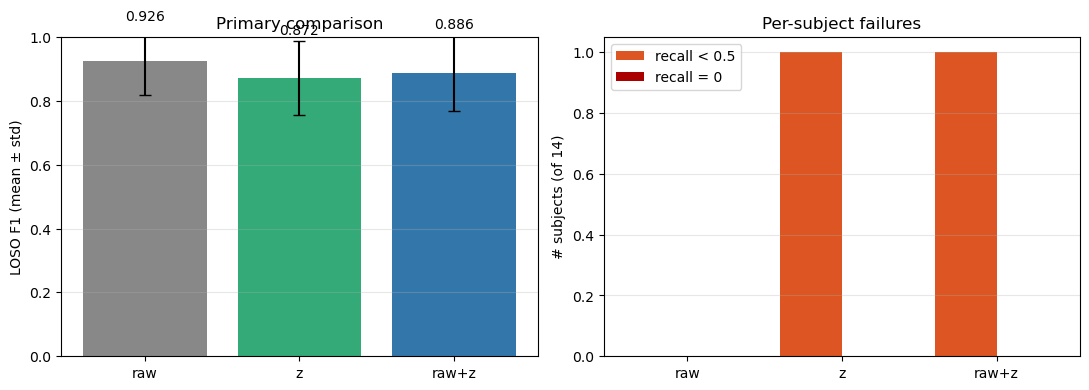

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
names = ['raw', 'z', 'raw+z']
f1s = [primary_results[n]['mean_f1'] for n in names]
stds = [primary_results[n]['std_f1'] for n in names]
ax.bar(names, f1s, yerr=stds, capsize=4, color=['#888', '#3a7', '#37a'])
ax.set_ylabel('LOSO F1 (mean ± std)'); ax.set_title('Primary comparison')
ax.set_ylim(0, 1); ax.grid(alpha=0.3, axis='y')
for i, (f, s) in enumerate(zip(f1s, stds)):
    ax.text(i, f + s + 0.02, f'{f:.3f}', ha='center')

ax = axes[1]
n_below = [primary_results[n]['n_subjects_recall_below_0_5'] for n in names]
n_zero  = [primary_results[n]['n_subjects_recall_zero']      for n in names]
x = np.arange(len(names))
ax.bar(x - 0.2, n_below, width=0.4, label='recall < 0.5', color='#d52')
ax.bar(x + 0.2, n_zero,  width=0.4, label='recall = 0',  color='#a00')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('# subjects (of 14)'); ax.set_title('Per-subject failures')
ax.legend(); ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'primary_comparison.png', dpi=120)
plt.show()

## §5 — Full sweep: add percent-change and robust z-score

Same dataset, two more strategies. Percent change is sensitive to near-zero baselines — V1's session log noted features where `_pct` had negative SHAP. Robust z replaces mean/std with median/MAD, which is more stable when baseline windows are noisy or short.

In [9]:
all_results = dict(primary_results)
for name, cols in [('pct', PCT_COLS), ('robust_z', RBZ_COLS)]:
    t0 = time.time()
    all_results[name] = ev.loso_evaluate(df_all, cols, model_factory=ev.hgb_factory())
    r = all_results[name]
    print(f'{name:>10s} ({len(cols):>3d} feats): F1={r["mean_f1"]:.3f}±{r["std_f1"]:.3f}  '
          f'recall={r["mean_recall"]:.3f}  min_subj_recall={r["min_subject_recall"]:.3f}  '
          f'#zero_recall={r["n_subjects_recall_zero"]}/{14}  ({time.time()-t0:.1f}s)')

summary = ev.summarize_results(all_results)
summary

       pct ( 48 feats): F1=0.836±0.233  recall=0.822  min_subj_recall=0.100  #zero_recall=0/14  (19.6s)
  robust_z ( 48 feats): F1=0.790±0.167  recall=0.814  min_subj_recall=0.364  #zero_recall=0/14  (12.4s)


,variant,mean_f1,std_f1,mean_recall,std_recall,mean_precision,mean_accuracy,min_subject_recall,n_subjects_recall_below_0_5,n_subjects_recall_zero
0,raw,0.925552,0.106009,0.898701,0.172256,0.977106,0.971558,0.545455,0,0
1,raw+z,0.886289,0.119243,0.857792,0.198896,0.951565,0.956716,0.454545,1,0
2,z,0.872438,0.115667,0.866126,0.177369,0.913305,0.944911,0.454545,1,0
3,pct,0.836061,0.232557,0.821537,0.262005,0.901786,0.936275,0.100000,2,0
4,robust_z,0.790174,0.166924,0.813745,0.252703,0.846526,0.908984,0.363636,3,0


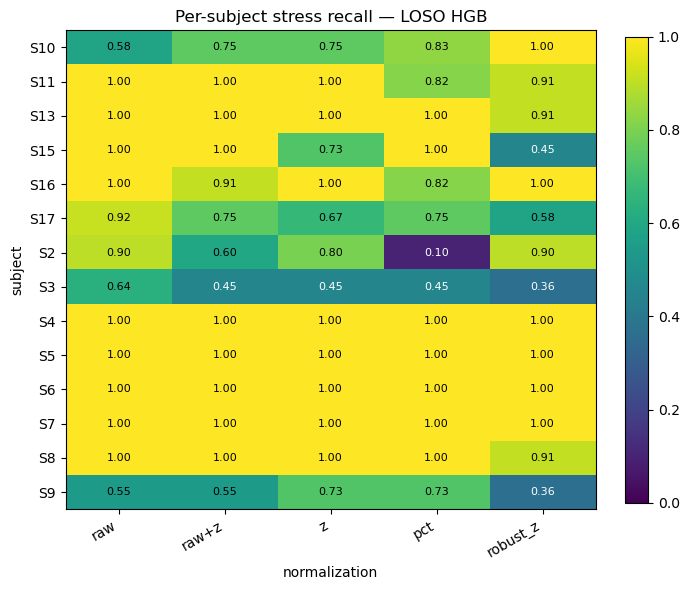

,raw,raw+z,z,pct,robust_z
S10,0.583333,0.750000,0.750000,0.833333,1.000000
S11,1.000000,1.000000,1.000000,0.818182,0.909091
S13,1.000000,1.000000,1.000000,1.000000,0.909091
S15,1.000000,1.000000,0.727273,1.000000,0.454545
S16,1.000000,0.909091,1.000000,0.818182,1.000000
S17,0.916667,0.750000,0.666667,0.750000,0.583333
S2,0.900000,0.600000,0.800000,0.100000,0.900000
S3,0.636364,0.454545,0.454545,0.454545,0.363636
S4,1.000000,1.000000,1.000000,1.000000,1.000000
S5,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
psr = ev.per_subject_recall_matrix(all_results)
psr = psr[summary['variant'].tolist()]  # column order = sorted-by-F1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(psr.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(len(psr.columns))); ax.set_xticklabels(psr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(psr.index))); ax.set_yticklabels(psr.index)
ax.set_xlabel('normalization'); ax.set_ylabel('subject')
ax.set_title('Per-subject stress recall — LOSO HGB')
for i in range(psr.shape[0]):
    for j in range(psr.shape[1]):
        v = psr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v < 0.5 else 'black', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(REPORTS_DIR / 'per_subject_heatmap.png', dpi=120)
plt.show()
psr

## §5.5 — V2 mixed-bucket scheme: physiology-guided raw/z assignment

The teammate's V2 pipeline (`Updated_Extraction_V2/extract_windowed_datasets.py:47-67`) used a three-bucket scheme based on physiological reasoning:

- **Bucket 1 (raw):** features without a meaningful per-subject baseline — movement magnitudes, distribution shape (skew/kurtosis), dimensionless ratios (LF/HF).
- **Bucket 2 (raw + z):** vital signs that have BOTH clinical absolute meaning AND per-subject deviation interest — HR, temp, SCR count.
- **Bucket 3 (z-only):** features whose absolute values are uninterpretable without baseline — SCL levels, SCR amplitudes, HRV time-domain.

Their notebook kept *both* raw and z for bucket 2. Our 48-feature budget can't accommodate that and stay apples-to-apples with our pure-raw and pure-z runs (also 48 each). To compare fairly we **pick z for bucket 2** since the teammate's gain analysis showed z versions dominated for those features.

V3 mapping (48 total = 15 raw + 33 z):
- **Bucket 1 raw (15):** all 12 ACC features (V3 added 4 over V2: `acc_activity_mean`, `acc_jerk_mag_mean/std/p95`) + `eda_skewness`, `eda_kurtosis`, `hrv_lf_hf_ratio`
- **Bucket 2 → z (8):** `hrv_mean_hr`, `hrv_rmssd`, `hrv_pnn50`, `temp_{mean,min,max,median}`, `scr_peak_count`
- **Bucket 3 z (25):** `scl_*` (8), `scr_amplitude_*` + rise/recovery (6), `temp_std`, `temp_slope`, HRV time-domain `sdnn`/`mean_rr`/`median_rr`/`sdsd`/`min_rr`/`max_rr` (6), HRV freq `lf_power`/`hf_power`/`total_power` (3 — V3 dropped vlf and sd1)

Hypothesis under test: the V2-style mix beats pure raw because absolute-scale features (Bucket 1) carry cross-subject context AND per-subject z-features (Buckets 2+3) capture deviation signal — the best of both. If raw still wins, we know the absolute-scale signal is doing all the work.

In [11]:
# V2 bucket assignments translated to V3's 48-feature catalog
BUCKET_1_RAW = [  # 15 features: no meaningful per-subject baseline
    'acc_x_std', 'acc_y_std', 'acc_z_std',
    'acc_magnitude_mean', 'acc_magnitude_std', 'acc_magnitude_max',
    'acc_sma', 'acc_energy',
    'acc_activity_mean', 'acc_jerk_mag_mean', 'acc_jerk_mag_std', 'acc_jerk_mag_p95',
    'eda_skewness', 'eda_kurtosis',
    'hrv_lf_hf_ratio',
]

BUCKET_2_PICK_Z = [  # 8 features: V2 had raw+z; we pick z (gain analysis preference)
    'hrv_mean_hr', 'hrv_rmssd', 'hrv_pnn50',
    'temp_mean', 'temp_min', 'temp_max', 'temp_median',
    'scr_peak_count',
]

BUCKET_3_Z = [  # 25 features: only meaningful relative to baseline
    'scl_mean', 'scl_std', 'scl_min', 'scl_max', 'scl_range', 'scl_median', 'scl_slope', 'scl_auc',
    'scr_amplitude_mean', 'scr_amplitude_max', 'scr_amplitude_std', 'scr_amplitude_sum',
    'scr_rise_time_mean', 'scr_recovery_time_mean',
    'temp_std', 'temp_slope',
    'hrv_sdnn', 'hrv_mean_rr', 'hrv_median_rr', 'hrv_sdsd', 'hrv_min_rr', 'hrv_max_rr',
    'hrv_lf_power', 'hrv_hf_power', 'hrv_total_power',
]

# Sanity: every V3 feature must appear in exactly one bucket, and total must be 48
all_bucketed = set(BUCKET_1_RAW) | set(BUCKET_2_PICK_Z) | set(BUCKET_3_Z)
missing_from_buckets = set(FEATURE_COLS) - all_bucketed
extra_in_buckets = all_bucketed - set(FEATURE_COLS)
assert not missing_from_buckets, f"V3 features not assigned to a bucket: {missing_from_buckets}"
assert not extra_in_buckets,    f"Bucketed features not in V3: {extra_in_buckets}"
assert len(all_bucketed) == 48, f"Buckets cover {len(all_bucketed)}, expected 48"
print(f'Bucket coverage OK: {len(BUCKET_1_RAW)} raw + {len(BUCKET_2_PICK_Z)} z (bucket-2)'
      f' + {len(BUCKET_3_Z)} z (bucket-3) = {len(all_bucketed)} unique features')

# Build the mixed-bucket column set
MIXED_COLS = (
    BUCKET_1_RAW
    + [f'{c}_z' for c in BUCKET_2_PICK_Z]
    + [f'{c}_z' for c in BUCKET_3_Z]
)
assert len(MIXED_COLS) == 48
print(f'Mixed-bucket feature set: {len(MIXED_COLS)} cols (15 raw + 33 z)\n')

# LOSO eval
mixed_results = ev.loso_evaluate(df_all, MIXED_COLS, model_factory=ev.hgb_factory())
r = mixed_results
print(f'  mixed (V2-bucket): F1={r["mean_f1"]:.3f}±{r["std_f1"]:.3f}  '
      f'recall={r["mean_recall"]:.3f}  min_subj={r["min_subject_recall"]:.3f}  '
      f'#below_0.5={r["n_subjects_recall_below_0_5"]}/14  '
      f'#zero={r["n_subjects_recall_zero"]}/14')

# Update the master results dict and re-rank
all_results['mixed (V2-bucket)'] = mixed_results
mixed_summary = ev.summarize_results(all_results)
print('\n=== Updated F1 ranking (all variants on the same 14-subject dataset) ===')
mixed_summary[['variant', 'mean_f1', 'std_f1', 'mean_recall',
               'min_subject_recall', 'n_subjects_recall_below_0_5']]

Bucket coverage OK: 15 raw + 8 z (bucket-2) + 25 z (bucket-3) = 48 unique features
Mixed-bucket feature set: 48 cols (15 raw + 33 z)

  mixed (V2-bucket): F1=0.851±0.138  recall=0.839  min_subj=0.364  #below_0.5=1/14  #zero=0/14

=== Updated F1 ranking (all variants on the same 14-subject dataset) ===


,variant,mean_f1,std_f1,mean_recall,min_subject_recall,n_subjects_recall_below_0_5
0,raw,0.925552,0.106009,0.898701,0.545455,0
1,raw+z,0.886289,0.119243,0.857792,0.454545,1
2,z,0.872438,0.115667,0.866126,0.454545,1
3,mixed (V2-bucket),0.850556,0.138162,0.838961,0.363636,1
4,pct,0.836061,0.232557,0.821537,0.100000,2
5,robust_z,0.790174,0.166924,0.813745,0.363636,3


Per-subject recall: mixed-bucket vs raw

       raw  mixed (V2-bucket)  delta_vs_raw
S10  0.583              0.750         0.167
S11  1.000              0.727        -0.273
S13  1.000              1.000         0.000
S15  1.000              0.727        -0.273
S16  1.000              1.000         0.000
S17  0.917              0.750        -0.167
S2   0.900              0.700        -0.200
S3   0.636              0.364        -0.273
S4   1.000              1.000         0.000
S5   1.000              1.000         0.000
S6   1.000              1.000         0.000
S7   1.000              1.000         0.000
S8   1.000              1.000         0.000
S9   0.545              0.727         0.182


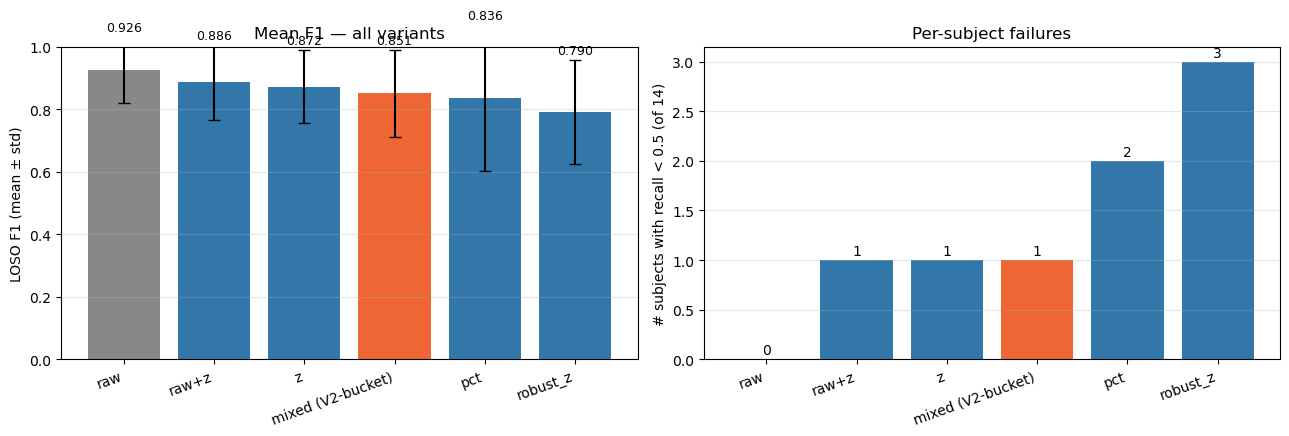

In [12]:
# Per-subject delta: mixed-bucket vs raw, side-by-side
diff_df = pd.DataFrame({
    'raw': pd.Series(all_results['raw']['per_subject_recall']),
    'mixed (V2-bucket)': pd.Series(all_results['mixed (V2-bucket)']['per_subject_recall']),
}).sort_index()
diff_df['delta_vs_raw'] = diff_df['mixed (V2-bucket)'] - diff_df['raw']
print('Per-subject recall: mixed-bucket vs raw\n')
print(diff_df.round(3).to_string())

# Quick visual: F1 across all five variants + mixed
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = mixed_summary['variant'].tolist()
ax = axes[0]
f1s = [all_results[v]['mean_f1'] for v in order]
stds = [all_results[v]['std_f1'] for v in order]
colors = ['#888' if v == 'raw' else ('#e63' if v == 'mixed (V2-bucket)' else '#37a') for v in order]
ax.bar(order, f1s, yerr=stds, capsize=4, color=colors)
ax.set_ylabel('LOSO F1 (mean ± std)')
ax.set_title('Mean F1 — all variants')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
for i, (f, s) in enumerate(zip(f1s, stds)):
    ax.text(i, f + s + 0.02, f'{f:.3f}', ha='center', fontsize=9)

ax = axes[1]
n_below = [all_results[v]['n_subjects_recall_below_0_5'] for v in order]
ax.bar(order, n_below, color=colors)
ax.set_ylabel('# subjects with recall < 0.5 (of 14)')
ax.set_title('Per-subject failures')
ax.grid(alpha=0.3, axis='y')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
for i, n in enumerate(n_below):
    ax.text(i, n + 0.05, str(n), ha='center', fontsize=10)

fig.tight_layout()
fig.savefig(REPORTS_DIR / 'all_variants_with_mixed.png', dpi=120)
plt.show()

## §6 — Calibration-length sub-experiment

Vary how much label=1 baseline data each subject's calibration uses: 5 / 10 / 15 minutes from the start of the session vs the full label=1 segment. Tests whether the deployment-time calibration period needs to be all of the resting baseline or whether a few minutes is enough.

Run on the **chosen normalization** from §5 (top of the F1 ranking).

In [13]:
# Pick the best variant from §5 (excluding any that's tied — pick first)
best_variant = summary.iloc[0]['variant']
print(f'Best variant from §5: {best_variant}')

best_kind = {'raw': None, 'z': 'z', 'pct': 'pct', 'robust_z': 'robust_z', 'raw+z': 'z'}[best_variant]
best_suffix = {'z': '_z', 'pct': '_pct', 'robust_z': '_rz'}.get(best_kind)

if best_kind is None:
    print('Best variant is raw — no calibration-length sweep applicable. Skipping.')
    cal_results = None
else:
    cal_minutes = [5, 10, 15, 'full']
    cal_results = {}
    for cm in cal_minutes:
        # Restrict baseline windows per subject
        if cm == 'full':
            base_subset = df_raw[df_raw['raw_label'] == 1]
        else:
            cap_sec = cm * 60
            # First N minutes of label=1 per subject (in window_start_sec)
            base_subset = pd.concat([
                g[g['raw_label'] == 1].nsmallest(int(cap_sec / WINDOW_SEC), 'window_start_sec')
                for _, g in df_raw.groupby('subject_id')
            ])
        # Per-subject stats over this restricted baseline
        stats_cm = {}
        for sid, g in base_subset.groupby('subject_id'):
            s = {}
            for c in FEATURE_COLS:
                x = g[c].dropna()
                s[c] = {
                    'mean':   x.mean()   if len(x) else np.nan,
                    'std':    x.std()    if len(x) else np.nan,
                    'median': x.median() if len(x) else np.nan,
                    'mad':    (x - x.median()).abs().median() if len(x) else np.nan,
                }
            stats_cm[sid] = s
        df_cm = apply_norm(df_raw, stats_cm, kind=best_kind, suffix=best_suffix)
        eval_df = pd.concat([df_raw[['subject_id', 'label', 'raw_label']], df_cm], axis=1)
        cols_cm = [f'{c}{best_suffix}' for c in FEATURE_COLS]
        if best_variant == 'raw+z':
            eval_df = pd.concat([eval_df, df_raw[FEATURE_COLS]], axis=1)
            cols_cm = FEATURE_COLS + cols_cm
        r = ev.loso_evaluate(eval_df, cols_cm, model_factory=ev.hgb_factory())
        cal_results[str(cm)] = r
        print(f'  cal={str(cm):>5s} min: F1={r["mean_f1"]:.3f}±{r["std_f1"]:.3f}  '
              f'recall={r["mean_recall"]:.3f}  #zero={r["n_subjects_recall_zero"]}/14')
    cal_summary = ev.summarize_results(cal_results)
    cal_summary

Best variant from §5: raw
Best variant is raw — no calibration-length sweep applicable. Skipping.


In [14]:
if cal_results is not None:
    fig, ax = plt.subplots(figsize=(7, 4))
    labels = list(cal_results.keys())
    f1s = [cal_results[k]['mean_f1'] for k in labels]
    stds = [cal_results[k]['std_f1'] for k in labels]
    recs = [cal_results[k]['mean_recall'] for k in labels]
    x = np.arange(len(labels))
    ax.errorbar(x, f1s, yerr=stds, marker='o', label='F1 (±std)', capsize=4, color='#37a')
    ax.plot(x, recs, marker='s', label='recall', color='#3a7')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_xlabel('calibration length (minutes; "full" = all label=1)')
    ax.set_ylabel('LOSO metric'); ax.set_ylim(0, 1)
    ax.set_title(f'Calibration-length sweep — variant {best_variant}')
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / 'calibration_length.png', dpi=120)
    plt.show()

## §7 — Findings & decision

*Interpret the results in the cells above.* The bullet points to look for:
- Which normalization wins on F1?
- Does any normalization recover S2/S3/S17 (the persistent failures from Phase 2)?
- Is `raw+z` measurably better than `z` alone, or is the extra parameter count costing us?
- **Does the V2 mixed-bucket scheme (15 raw + 33 z, physiology-guided) beat pure raw?** If yes, the V2 author was directionally right and we should adopt their bucket logic in Phase 5. If no, the absolute-scale signal in Bucket 2/3 features is doing real work that z-scoring throws away.
- Does calibration length matter, or is 5 min as good as full baseline?

Once we have a winner, we lock it for Phase 5 (feature selection). The chosen variant + calibration length goes into `docs/04_normalization.md` and `Updated_Extraction_V3/config.yaml`.

In [15]:
# Save tables for the docs to reference. Use the most-complete summary if §5.5 was run.
final_summary = mixed_summary if 'mixed_summary' in dir() else summary
final_psr = ev.per_subject_recall_matrix(all_results)[final_summary['variant'].tolist()]

final_summary.to_csv(REPORTS_DIR / 'normalization_summary.csv', index=False)
final_psr.to_csv(REPORTS_DIR / 'per_subject_recall.csv')
if cal_results is not None:
    cal_summary.to_csv(REPORTS_DIR / 'calibration_length_summary.csv', index=False)
print(f'Wrote results to {REPORTS_DIR.relative_to(REPO_ROOT)}/')
for f in sorted(REPORTS_DIR.iterdir()):
    print(f'  {f.name}')

Wrote results to reports\04_normalization/
  all_variants_with_mixed.png
  normalization_summary.csv
  per_subject_heatmap.png
  per_subject_recall.csv
  primary_comparison.png
